# APEX — PTB-XL Exploratory Data Analysis (Phase 1)

Label distribution, class imbalance, demographics, and the patient-level split that
feeds the train/val/test manifests. **Metadata only** — no signal files required.

Run top-to-bottom with the project venv kernel. The tabular/plot helpers live in
`src/data/eda.py` so this notebook and `scripts/run_eda.py` stay in sync.

In [1]:
import sys
from pathlib import Path
# make `import src...` work when the kernel's cwd is notebooks/
ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from src.data import labels as L, eda

df = L.load_database()
scp = L.load_scp_statements()
len(df), len(L.build_label_space())

(21799, 71)

## 1. Dataset shape & demographics

In [2]:
demo = eda.demographics_summary(df)
demo

{'n_records': 21799,
 'n_patients': 18869,
 'age_median': 61.0,
 'age_mean': 59.5,
 'age_anonymized_300': 293,
 'age_missing': 293,
 'sex_male': 11354,
 'sex_female': 10445,
 'n_devices': 11,
 'n_sites': 51}

PTB-XL v1.0.3: **21,799** records from **18,869** patients. Note `age=300` is
PTB-XL's anonymization sentinel for patients >89 (excluded from age stats).

## 2. Label space & class imbalance
All 71 SCP statements, ranked by prevalence.

In [3]:
prev = eda.code_prevalence(df, scp)
prev.head(15)

,code,count,prevalence_%,description,diagnostic,form,rhythm
0,SR,16748,76.829,sinus rhythm,False,False,True
1,NORM,9514,43.644,normal ECG,True,False,False
2,ABQRS,3327,15.262,abnormal QRS,False,True,False
3,IMI,2676,12.276,inferior myocardial infarction,True,False,False
4,ASMI,2357,10.812,anteroseptal myocardial infarction,True,False,False
5,LVH,2132,9.780,left ventricular hypertrophy,True,False,False
6,NDT,1825,8.372,non-diagnostic T abnormalities,True,True,False
7,LAFB,1623,7.445,left anterior fascicular block,True,False,False
8,AFIB,1514,6.945,atrial fibrillation,False,False,True
9,ISC_,1272,5.835,non-specific ischemic,True,False,False


In [4]:
print("rarest 10 statements:")
prev.tail(10)[["code", "count", "description"]]

rarest 10 statements:


,code,count,description
61,SVTAC,27,supraventricular tachycardia
62,PSVT,24,paroxysmal supraventricular tachycardia
63,TRIGU,20,"trigeminal pattern (unknown origin, SV or Vent..."
64,INJIN,18,subendocardial injury in inferior leads
65,INJLA,17,subendocardial injury in lateral leads
66,PMI,17,posterior myocardial infarction
67,3AVB,16,third degree AV block
68,INJIL,15,subendocardial injury in inferolateral leads
69,2AVB,14,second degree AV block
70,PRC(S),10,premature complex(es)


23 of 71 statements appear in <100 records — heavy long tail.


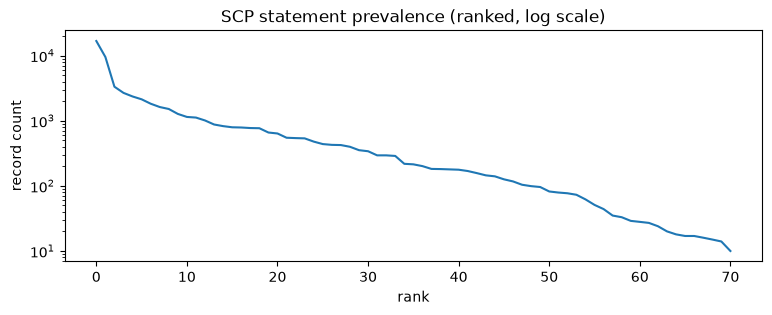

In [5]:
n_rare = int((prev["count"] < 100).sum())
print(f"{n_rare} of 71 statements appear in <100 records — heavy long tail.")
prev["count"].plot(kind="line", logy=True, figsize=(9,3),
                   title="SCP statement prevalence (ranked, log scale)",
                   xlabel="rank", ylabel="record count");

### Diagnostic superclasses (the 5-way coarse grouping)

,superclass,count,prevalence_%
0,NORM,9514,43.64
1,MI,5469,25.09
2,STTC,5235,24.01
3,CD,4898,22.47
4,HYP,2649,12.15


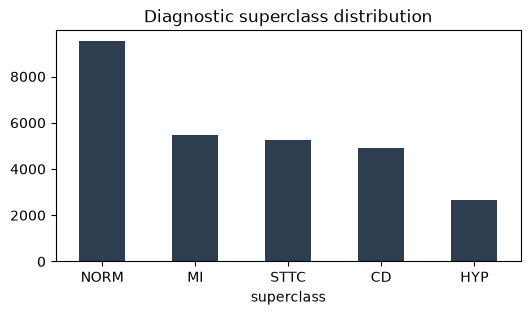

In [6]:
sc = eda.superclass_prevalence(df, scp)
ax = sc.set_index("superclass")["count"].plot(kind="bar", figsize=(6,3),
        title="Diagnostic superclass distribution", rot=0, color="#2c3e50")
sc

## 3. Multi-label density
ECGs commonly carry several concurrent statements.

labels/record — mean 2.80, median 2, max 9


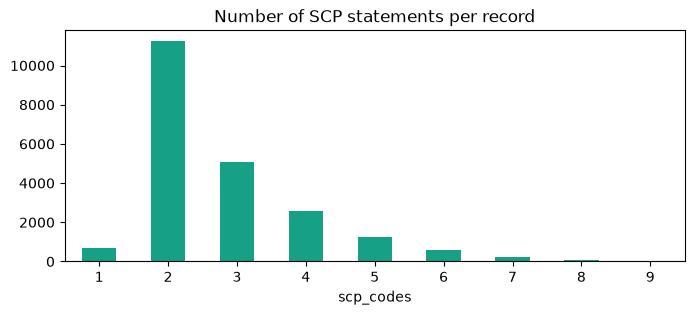

In [7]:
lpr = eda.labels_per_record(df)
print("labels/record — mean %.2f, median %d, max %d" % (lpr.mean(), lpr.median(), lpr.max()))
lpr.value_counts().sort_index().plot(kind="bar", figsize=(8,3),
        title="Number of SCP statements per record", rot=0, color="#16a085");

## 4. Records per patient → why we split by patient

In [8]:
rpp = eda.records_per_patient(df)
multi = int((rpp > 1).sum())
print(f"{multi:,} patients have >1 recording (max {int(rpp.max())}).")
print("Splitting by *record* would leak the same patient across train/test.")
print("PTB-XL's official strat_fold is assigned per patient, so we split on it.")

2,111 patients have >1 recording (max 10).
Splitting by *record* would leak the same patient across train/test.
PTB-XL's official strat_fold is assigned per patient, so we split on it.


## 5. Train/val/test manifests (split by patient)
Folds 1-8 = train, 9 = val, 10 = test. We assert no patient spans two splits.

In [9]:
from src.data import manifests as M
manifest = M.build_manifest(df, scp)
M.assert_no_patient_leakage(manifest)   # raises if any patient leaks
print("no patient leakage across splits ✓")
manifest.groupby("split").size().rename("records")

no patient leakage across splits ✓


split
test      2198
train    17418
val       2183
Name: records, dtype: int64

In [10]:
# superclass balance is preserved across splits
manifest.groupby("split")[[f"sc_{s}" for s in L.DIAGNOSTIC_SUPERCLASSES]].mean().round(3)

,sc_NORM,sc_MI,sc_STTC,sc_CD,sc_HYP
split,,,,,
test,0.438,0.250,0.237,0.226,0.119
train,0.436,0.251,0.240,0.224,0.122
val,0.437,0.247,0.242,0.227,0.123


## Takeaways for modeling
- **Severe imbalance**: `SR`/`NORM` dominate; ~23 statements have <100 records. Use
  macro-averaged metrics + class weighting / focal loss; watch the rare tail.
- **Multi-label**: most records have 2+ statements → sigmoid heads, per-label thresholds.
- **Patient-level splits** are mandatory; the official folds already enforce this.
- **Start coarse**: validate on the 5 diagnostic superclasses / 44 diagnostic
  statements before the full 71.

Manifests are written by `python -m src.data.manifests`; figures/tables by
`python scripts/run_eda.py` (see `docs/eda/`).